In [1]:
import os
import sys
import importlib
import pandas as pd
import numpy as np
import nibabel as nib
import networkx as nx

sys.path.append('/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/')
import gen
import bids_naming as names
importlib.reload(names)

import projectUtils as prjUtils
import visUtils as vis


In [ ]:
# 3 Possible approaches:
## 1. Bridgehead reference
## find nearest bridgehead to each vertex
## A-P: 
### assign each bridgehead an anterior-posterior position
### propogate AP position of that bridgehead

## allo-neo:
### get distance from bridgehead to each vertex. 
### If moving onto a hippocampal label, then assign distance being positive, else negative.


## 2. Boundary reference
### define boundary vertices along both axes (source=1, sink=2)

## 3. Find contour, then define allocortex vertices, compute distance from each point to these vertices. 
# Take min of each vertex, use this as alloNeo dimension
# use Y-value as AP dimension.

In [2]:
# boundary approach [glasser parc]:
## Anterior boundary:
### take vertices in PeEC
importlib.reload(prjUtils)
importlib.reload(vis)
lbl_info = {
    'root':'/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/',
    'lbl_gii_pth':"stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp.label.gii",
    'lbl_csv_pth':"stitch_lblValDetails_ctx-glsr_hipp-DK25_12Feb2026-0915.csv",
    'lbl_col':['SName'],
    'colName_lblIdx': 'idx',
    'colName_lblName': 'SName',
    'colourCols': True
}

limits = {
    "ap": [['PeEc'], ['VVC']], #anterior-posterior; [src_lbl,snk_lbl],
    "an": [['DG'], ['TF']], #medial-lateral; [src_lbl,snk_lbl]
}

test_pt_dir = "/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/"
test_surf = "sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched_mTemp-mask-ctx-glsr_hipp-DK25_12Feb2026.surf.gii"

lbl_details = pd.read_csv(os.path.join(lbl_info['root'], lbl_info['lbl_csv_pth']))

date = "13Feb2026"
mask_gii_pths = []
mask_giis = []


In [3]:
# create mask for each parcel and visualize
for axis in limits.keys():
    print(f"Axis {axis}")
    
    for lbl_dict in limits[axis]:
        lbl_indices = lbl_details.loc[
            lbl_details['SName'].isin(lbl_dict),  # match any value in list lbl
            'idx'
        ].tolist()
        print(f"{lbl_dict}: {lbl_indices}")
        
        # make mask
        mask_gii, mask_gii_pth = prjUtils.make_mask(lbl_pth=os.path.join(lbl_info['root'], lbl_info['lbl_gii_pth']),
                                      csv_pth=os.path.join(lbl_info['root'], lbl_info['lbl_csv_pth']), 
                                      label_col=lbl_info['lbl_col'], 
                                      label_vals=[lbl_dict],
                                      savePath=os.path.join(lbl_info['root'], "subMasks"),
                                      saveName=f"mask-{lbl_dict[0]}.gii")
        mask_gii_pths.append(mask_gii_pth)

        # apply to labels
        lbl_mask = prjUtils.apply_mask_to_stitchedGii(
                        pth_input_gii = os.path.join(lbl_info['root'], lbl_info['lbl_gii_pth']),
                        pth_mask = mask_gii_pth,
                        pth_out = os.path.join(lbl_info['root'], "subMasks", lbl_info['lbl_gii_pth'].replace(".label.gii",f"_mask-{lbl_dict[0]}.label.gii")),
                        apply_to_labels=True
                        )

        # apply to surface
        surf_mask = prjUtils.apply_mask_to_stitchedGii(
                        pth_input_gii = os.path.join(test_pt_dir, test_surf),
                        pth_mask = mask_gii_pth,
                        pth_out = os.path.join(test_pt_dir, test_surf.replace(".surf.gii",f"mask-{lbl_dict[0]}.surf.gii")),
                        )
        # visualize
        vis.vis_lbls_on_surf(surf_pth=surf_mask, 
                             lbl_pth=lbl_mask,
                             lbl_csvInfo=lbl_info,
                             out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/"
                            )

Axis ap
['PeEc']: [122]
Processing column 'SName' for label values: ['PeEc']...
Column 'SName' - Label values ['PeEc'] found in rows: [122]
Target labels for mask (after deduplication) (1): [122]
Mask saved to: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/subMasks/mask-PeEc.gii.gii
	Vertices: 8477 → 312
	Saved [2KB]: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/subMasks/stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp_mask-PeEc.label.gii
	Vertices: 8477 → 312
	Saved [8KB]: /host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched_mTemp-mask-ctx-glsr_hipp-DK25_12Feb2026mask-PeEc.surf.gii
Visualization saved to: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched_mTemp-mask-ctx-glsr_hipp-DK25_12Feb202

In [4]:
importlib.reload(prjUtils)
importlib.reload(vis)

def positive_direction(voi_coords_xyz:np.ndarray, xyz_axis:int, thresh_distance:float, method = "5per",verbose=False) -> np.ndarray:
    if method == 'range':
        edge_xTreme_coord = np.max(voi_coords_xyz[:, xyz_axis])
    elif method == '1per':
        edge_xTreme_coord = np.percentile(voi_coords_xyz[:, xyz_axis], 99) # use 99th percentile to avoid outliers driving the max coordinate
    elif method == '5per':
        edge_xTreme_coord = np.percentile(voi_coords_xyz[:, xyz_axis], 95) # use 95th percentile to avoid outliers driving the max coordinate
    
    coord_thresh = edge_xTreme_coord - thresh_distance
    edge_mask = (voi_coords_xyz[:, xyz_axis] >= coord_thresh) # take values at thresh and above

    if verbose:
        n_vertices_mask = np.sum(edge_mask)
        print(f"\t\t[+ dir] {n_vertices_mask} vertices with {xyz_name}-axis coordinate above {coord_thresh} [value (method:{method}): {edge_xTreme_coord}, offset: {thresh_distance}mm].")

    return edge_mask

def negative_direction(voi_coords_xyz:np.ndarray, xyz_axis:int, thresh_distance:float, method = "5per", verbose=False) -> np.ndarray:
    if method == 'range':
        edge_xTreme_coord = np.min(voi_coords_xyz[:, xyz_axis])
    elif method == '1per':
        edge_xTreme_coord = np.percentile(voi_coords_xyz[:, xyz_axis], 1) # use 1st percentile to avoid outliers driving the min coordinate
    elif method == '5per':
        edge_xTreme_coord = np.percentile(voi_coords_xyz[:, xyz_axis], 5) # use 5th percentile to avoid outliers driving the min coordinate
    
    coord_thresh = edge_xTreme_coord + thresh_distance
    edge_mask = (voi_coords_xyz[:, xyz_axis] <= coord_thresh) # take values at thresh and below
    
    if verbose:
        n_vertices_mask = np.sum(edge_mask)
        print(f"\t\t[- dir] {n_vertices_mask} vertices with {xyz_name}-axis coordinates lower than {coord_thresh} [value (method:{method}): {edge_xTreme_coord}, offset: {thresh_distance}mm)].")

    return edge_mask


# take all vertices within 0.5mm of the edge:
# ## PeEc: from anterior
# ## VVC: from posterior
# ## DG: all vertices
# ## TF: from lateral

limits = {
    "antPost": [
        {
            'type': 'src',
            'lbl_name': ['PeEc'], # glsr
            'lbl_csvCol': 'SName',
            'edge_dir': 'anterior',
            'distance': 0.25
        },
        {
            'type': 'snk',
            'lbl_name': ['VVC'], # glsr
            'lbl_csvCol': 'SName',
            'edge_dir': 'posterior',
            'distance': 0.25
        }
    ],

    "alloNeo": [
             {
                'type': 'src', 
                'lbl_name': [196,206],
                'lbl_csvCol': 'idx',
                'edge_dir': 'medial', # because of curvature of hippocampus
                'distance': 0.1,
            },
           {
                'type': 'snk', 
                'lbl_name': ['TF'],
                'lbl_csvCol': 'SName',
                'edge_dir': 'lateral',
                'distance': 0.25,
            }
            ], #medial-lateral; [src_lbl,snk_lbl]
}

verbose = True
surf_pth = os.path.join(test_pt_dir, test_surf)

surf_hemi =  prjUtils.get_hemi_from_pth(surf_pth)
#print(f"Surface hemisphere: {surf_hemi}")
surf_xyz = nib.load(surf_pth).darrays[0].data
print(f"surface file xyz structure: {str(surf_xyz.shape)}")

lbl_data = nib.load(os.path.join(lbl_info['root'], lbl_info['lbl_gii_pth'])).darrays[0].data # labels
print(f"label file structure: {str(lbl_data.shape)}")

edge_lbl_pths = []
for axis in limits.keys():
    print(f"Axis {axis}")
    # create new label.gii object to store edge label (1: source, 2: sink, 0: not edge)
    edge_mask_pth = nib.gifti.GiftiImage()
    edge_mask_pth = np.zeros(lbl_data.shape, dtype=np.int32) # initialize as 0
    
    for lbl_dict in limits[axis]:

        lbl_name = lbl_dict['lbl_name']
        lbl_indices = lbl_details.loc[
            lbl_details[lbl_dict['lbl_csvCol']].isin(lbl_name),  # match any value in list lbl
            'idx' # col of label index values to return 
        ].tolist()
        
        voi = []
        voi = np.where(lbl_data == lbl_indices[0])[0] # get indices for vertices of interest
        print(f"\t`{lbl_name}`:{lbl_indices} | {len(voi)} vertices: {voi}")
        
        voi_coords_xyz = surf_xyz[voi]

        # determine xyz axis of use for this new axis
        xyz_axis, xyz_name = prjUtils.get_xyz_axis_latDir(axis_name=axis)

        # Associate edge labels with appropriate vertices
        if lbl_dict['distance'] == 0: # assign all vertices the label
            edge_mask_pth = np.ones(voi_coords_xyz.shape[0], dtype=bool)
            print(f"\t\tTaking all {len(voi_coords_xyz)} vertices in {lbl_name} as edge (distance=0)")
        
        elif lbl_dict['edge_dir'] in ["anterior", "superior"]: # positive direction along axis
            edge_mask_pth = positive_direction(voi_coords_xyz, xyz_axis, lbl_dict['distance'], verbose=verbose)

        elif lbl_dict['edge_dir'] in ["posterior", "inferior"]: # negative direction along axis
            edge_mask_pth = negative_direction(voi_coords_xyz, xyz_axis, lbl_dict['distance'], verbose=verbose)

        elif surf_hemi == 'R' and lbl_dict['edge_dir'] == 'medial': # negative direction along axis
            edge_mask_pth = negative_direction(voi_coords_xyz, xyz_axis, lbl_dict['distance'], verbose=verbose)

        elif surf_hemi == 'L' and lbl_dict['edge_dir'] == 'medial': # positive direction along axis
            edge_mask_pth = positive_direction(voi_coords_xyz, xyz_axis, lbl_dict['distance'], verbose=verbose)

        elif surf_hemi == 'R' and lbl_dict['edge_dir'] == 'lateral': # positive direction along axis
            edge_mask_pth = positive_direction(voi_coords_xyz, xyz_axis, lbl_dict['distance'], verbose=verbose)

        elif surf_hemi == 'L' and lbl_dict['edge_dir'] == 'lateral': # negative direction along axis
            edge_mask_pth = negative_direction(voi_coords_xyz, xyz_axis, lbl_dict['distance'], verbose=verbose)
        else:
            raise ValueError(f"Invalid edge direction `{lbl_dict['edge_dir']}` for label `{lbl_name}`. Must be one of: anterior, posterior, superior, inferior, medial, lateral.")
        
        # for all vertices in the edge_mask, assign lbl_index in new label.gii
        if lbl_dict['type'] == 'src':
            lbl_index = 1
        else: # sink
            lbl_index = 2
        edge_mask_pth[voi[edge_mask_pth]] = lbl_index
        print(f" Number of non-0 vertices: {np.sum(edge_mask_pth)}: {np.where(edge_mask_pth)[0]}")

    # save edge mask label.gii
    edge_mask_pth.add_gifti_data_array(nib.gifti.GiftiDataArray(edge_mask_pth, intent='NIFTI_INTENT_LABEL'))
    save_pth = os.path.join(lbl_info['root'], f"edgeMask-{axis}_{date}.label.gii")
    nib.save(edge_mask_pth, save_pth)
    edge_lbl_pths.append(save_pth)
    print(f"Saved {axis} edge mask: {save_pth}")

importlib.reload(vis)
for axis, lbl_pth in zip(limits.keys(), edge_lbl_pths):
    #print(f"{axis}: {lbl_pth}")
    vis.vis_lbls_on_surf(surf_pth = surf_pth, lbl_pth = lbl_pth, 
                         out_name = f"edgeMask-{axis}_{gen.fmt_now()}.png",
                         out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/")


surface file xyz structure: (8477, 3)
label file structure: (8477,)
Axis antPost
	`['PeEc']`:[122] | 312 vertices: [ 113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  152  153  154  155  156  157  158  159  160  161
  162  163  164  165  166  167  168  169  170  171  172  173  174  178
  179  180  181  182  183  184  195  196  197  198  199  200  201  202
  218  219  220  221  222  223  224  225  226  227  247  248  249  250
  251  252  253  254  255  256  276  277  278  279  280  281  282  283
  284  285  304  305  306  307  308  309  310  311  312  313  332  333
  334  335  336  337  338  339  340  341  359  360  361  362  363  364
  365  366  367  368  385  386  387  388  389  390  391  392  393  394
  411  412  413  414  415  416  417  418  419  436  437  438  439  440
  441  442  443  444  461  462  463  464  465  466  467  468  469  485
  486  487  488  489  490  491  4

IndexError: index 886 is out of bounds for axis 0 with size 312

In [ ]:
# BOUNDARY APPROACH
def find_boundary_vertices_numpy(faces_raw, n_vertices):
    """Find boundary vertices using face adjacency counting"""
    # Count how many faces each vertex belongs to
    vertex_face_count = np.zeros(n_vertices, dtype=int)
    
    for face in faces_raw:  # faces_raw shape: (N_faces, 3)
        vertex_face_count[face[0]] += 1
        vertex_face_count[face[1]] += 1  
        vertex_face_count[face[2]] += 1
    
    # Boundary vertices = those belonging to < 5 faces typically
    boundary_verts = np.where(vertex_face_count < 5)[0]
    return boundary_verts

surf_pth = os.path.join(test_pt_dir, test_surf)
surf = nib.load(surf_pth)
vertices = surf.darrays[0].data
faces_raw = surf.darrays[1].data
n_vrtx = len(vertices)

boundary_vertices = find_boundary_vertices_numpy(faces_raw, n_vrtx)
#print(f"Found {len(boundary_vertices)} boundary vertices: first 10 - {boundary_vertices[:10]}")

edge_mask = np.zeros(lbl_data.shape, dtype=np.int32) # initialize as 0
edge_mask[boundary_vertices] = 1

gii_img = nib.gifti.GiftiImage()
gii_img.add_gifti_data_array(nib.gifti.GiftiDataArray(edge_mask, intent='NIFTI_INTENT_LABEL'))

save_pth = os.path.join(lbl_info['root'], f"edgeMask-boundaryVertices_{date}.label.gii")
nib.save(gii_img, save_pth)
print(f"Saved boundary vertex mask: {save_pth}")

vis.vis_lbls_on_surf(surf_pth = surf_pth, lbl_pth = save_pth, 
                         out_name = f"edgeMask.png",
                         out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/")

In [271]:
# GET PART OF BOUNDARY ALONG MEDIAL HIPPOCAMPAL SURFACE
# [did not work] intersect edge with CA4/DG label
# [did not work] vertex values from unfolded hippunfold space... vertex indices are changed in my stitching, masking

# Fixed variable name + complete Z-filter logic
hipp_lbls = {
    'ft_colName': "lblSrc",
    'value': ['DeKraker25']
}

lbl_details = pd.read_csv(os.path.join(lbl_info['root'], lbl_info['lbl_csv_pth']))
hipp_lbl_indices = lbl_details.loc[  # Fixed variable name
    lbl_details[hipp_lbls['ft_colName']].isin(hipp_lbls['value']), 
    'idx'
].tolist()

# Get ALL hippocampal vertices
voi_hipp = []
for lbl_idx in hipp_lbl_indices:  # Fixed variable name
    voi_temp = np.where(lbl_data == lbl_idx)[0]
    voi_hipp.extend(voi_temp)

# Hippocampal boundary vertices (label 2 candidates)
voi_hipp_boundary = np.intersect1d(voi_hipp, boundary_vertices)

# Create 4-level mask
boundary_hipp_mask = np.zeros(lbl_data.shape, dtype=np.int32)

# Level 1: ALL boundary vertices (non-hippocampal)
boundary_hipp_mask[boundary_vertices] = 1

# Level 2: Hippocampal boundary vertices (ALL z-values)  
boundary_hipp_mask[voi_hipp_boundary] = 2

# Level 3: Hippocampal boundary vertices WITH Z in [-25, 20]
z_limits = (-25, 20)
hipp_boundary_lateral_indices = []

for idx in voi_hipp_boundary:
    z_val = vertices[idx, 2]  # Extract Z coordinate
    if z_limits[0] <= z_val <= z_limits[1]:
        hipp_boundary_lateral_indices.append(idx)

# Apply level 3 (overwrites level 2 for lateral hippocampus)
boundary_hipp_mask[hipp_boundary_lateral_indices] = 3

# Save
gii_img = nib.GiftiImage()
gii_img.add_gifti_data_array(nib.gifti.GiftiDataArray(boundary_hipp_mask, intent='NIFTI_INTENT_LABEL'))
save_pth = os.path.join(lbl_info['root'], f"edgeMask-boundaryVertices_hippOverlap_{date}.label.gii")
nib.save(gii_img, save_pth)
print(f"Saved 4-level boundary mask: {save_pth}")
print(f"Level 1 (boundary): {np.sum(boundary_hipp_mask == 1)} vertices")
print(f"Level 2 (hipp boundary): {np.sum(boundary_hipp_mask == 2)} vertices") 
print(f"Level 3 (hipp lateral): {np.sum(boundary_hipp_mask == 3)} vertices")

vis.vis_lbls_on_surf(surf_pth = surf_pth, lbl_pth = save_pth, 
                         out_name = f"edgeMask_hipp_bound.png",
                         out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/")


Saved 4-level boundary mask: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/edgeMask-boundaryVertices_hippOverlap_12Feb2026.label.gii
Level 1 (boundary): 159 vertices
Level 2 (hipp boundary): 64 vertices
Level 3 (hipp lateral): 464 vertices
Visualization saved to: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/edgeMask_hipp_bound.png


'/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/edgeMask_hipp_bound.png'

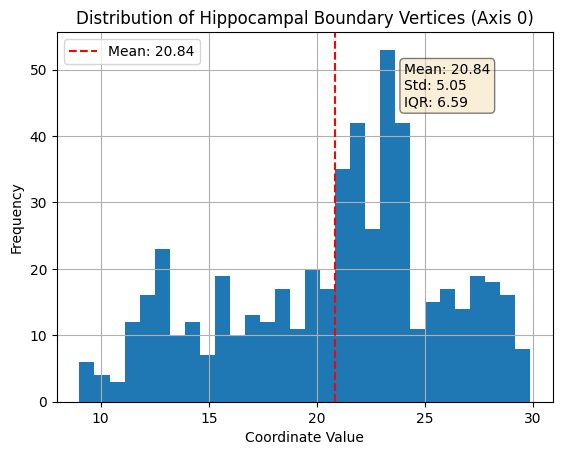

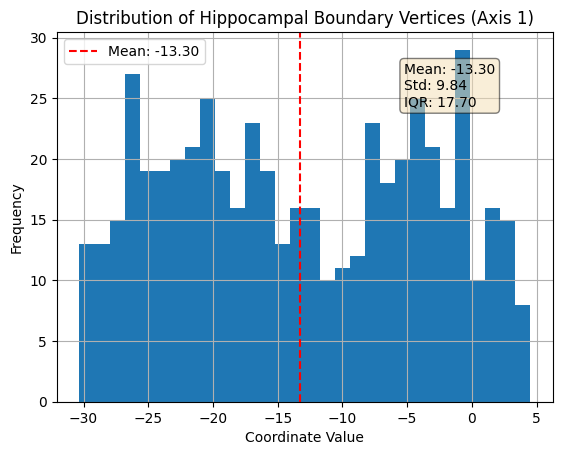

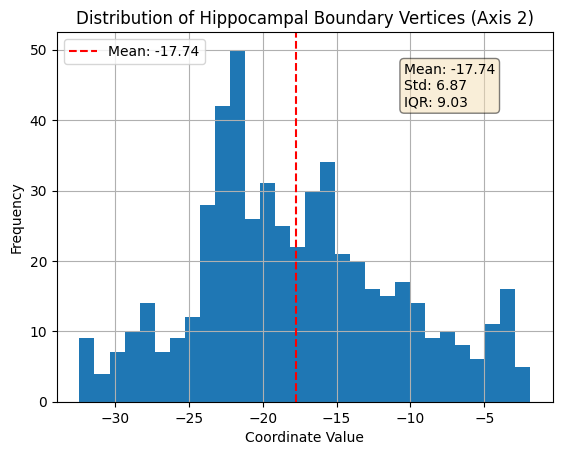

In [265]:
import matplotlib.pyplot as plt

# plot_distribtuion_xyz coords
for axis in range(3):
    plt.figure()
    plt.hist(hipp_boundary_coords[:, axis], bins=30)
    plt.title(f"Distribution of Hippocampal Boundary Vertices (Axis {axis})")
    plt.xlabel("Coordinate Value")
    plt.ylabel("Frequency")
    
    # Calculate and add statistics
    mean_val = np.mean(hipp_boundary_coords[:, axis])
    std_val = np.std(hipp_boundary_coords[:, axis])
    q25 = np.percentile(hipp_boundary_coords[:, axis], 25)
    q75 = np.percentile(hipp_boundary_coords[:, axis], 75)
    iqr = q75 - q25
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.text(0.7, 0.8, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}\nIQR: {iqr:.2f}', 
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    plt.grid()
    plt.legend()
    plt.show()


In [ ]:
from nibabel.nifti1 import intent_codes
import stitchSurfs as stitch
import subprocess as sp


unfold = nib.load("/data/mica3/BIDS_PNI/derivatives/hippunfold_v1.3.0/hippunfold/sub-PNC001/ses-01/surf/sub-PNC001_ses-01_hemi-L_space-unfold_den-0p5mm_label-hipp_midthickness.surf.gii")
unfold_V = np.asarray([da.data for da in unfold.darrays if da.intent == intent_codes['NIFTI_INTENT_POINTSET']][0])

print(np.min(unfold_V,axis=0))
print(np.max(unfold_V,axis=0))
bridgehead = np.where(unfold_V[:,1] > -180.3)[0]
print(len(bridgehead))
print(bridgehead)

# edge vertices

# stitch but unmasked surface
template = stitch.load_template("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/overlap_stitch_template_JD_Jan2026.pkl")
CA4idx_stitched = bridgehead + len(template.keep_cortex_idx)
print(CA4idx_stitched)


# for each other vertex, return list of distances to all of these CA4 vertices
# compute all vertex distances on stitched but not masked surface
# compute vertex wise differences:
surf_rt = "/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/"
surf_pth = "sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched.surf.gii"
out_pth = "vrtx_distances_sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched.dconn.nii"

cmd = f"wb_command -surface-geodesic-distance-all-to-all {os.path.join(surf_rt, surf_pth)} {os.path.join(lbl_info['root'], out_pth)}"
sp.run(cmd, shell=True)

# take minimum distance as value for alloNeo axis

[ -39.765625 -199.76562     1.171875]
[  -0.234375 -180.23438     1.171875]
152
[   3    5   29   59  105  115  168  180  266  330  393  403  436  495
  586  701  734  877 1743 2009 2256 2272 2276 2516 2523 2758 2958 2972
 3153 3168 3402 3421 3666 3668 3670 4076 4079 4080 4081 4658 4908 5061
 5080 5169 5170 5259 5260 5468 5524 5680 5738 5855 5880 5934 6007 6029
 6052 6118 6133 6210 6223 6262 6287 6301 6337 6360 6375 6377 6403 6428
 6429 6461 6463 6485 6497 6498 6523 6540 6569 6603 6605 6647 6651 6673
 6674 6678 6706 6731 6732 6734 6763 6764 6765 6794 6795 6796 6797 6798
 6832 6833 6834 6835 6867 6868 6869 6870 6871 6872 6895 6896 6897 6898
 6899 6900 6901 6934 6935 6936 6937 6938 6939 6940 6941 6942 6943 6944
 6945 6946 6947 6948 6974 6975 6976 6977 6978 6979 6980 6981 6982 6983
 6984 6985 7025 7026 7027 7028 7029 7030 7031 7063 7064 7065]
[30482 30484 30508 30538 30584 30594 30647 30659 30745 30809 30872 30882
 30915 30974 31065 31180 31213 31356 32222 32488 32735 32751 32755 32995
 3

CompletedProcess(args='wb_command -surface-geodesic-distance-all-to-all /host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched.surf.gii vrtx_distances_sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched.dconn.nii', returncode=0)

In [ ]:
# GET PART OF BOUNDARY ALONG MEDIAL HIPPOCAMPAL SURFACE
# [did not work] intersect edge with CA4/DG label
# [did not work] vertex values from unfolded hippunfold space... vertex indices are changed in my stitching, masking

# overlap edge masks with any hippocampal label
hipp_lbls = {
    'ft_colName': "lblSrc",
    'value': ['DeKraker25']
}

lbl_details = pd.read_csv(os.path.join(lbl_info['root'], lbl_info['lbl_csv_pth']))
hipp_lbl = lbl_details.loc[
    lbl_details[hipp_lbls['ft_colName']].isin(hipp_lbls['value']),  # match any value in list lbl
    'idx' # col of label index values to return
].tolist()

voi_hipp = []
for lbl_idx in lbl_indices:
    voi_temp = np.where(lbl_data == lbl_idx)[0]  # Vertices with this exact label
    voi_hipp.extend(voi_temp)
voi_hipp_boundary = np.intersect1d(voi_hipp, boundary_vertices)

boundary_hipp_mask = np.zeros(lbl_data.shape, dtype=np.int32)

# Label 1: ALL boundary vertices
boundary_hipp_mask[boundary_vertices] = 1

# Label 2: ONLY hippocampal boundary vertices (intersection)
boundary_hipp_mask[voi_hipp_boundary] = 2 

# get coordinates for the vertices lavelled as 2 (hippocampal boundary vertices)
hipp_boundary_coords = vertices[voi_hipp_boundary]
print(f"Coordinates of hippocampal boundary vertices (first 10): {hipp_boundary_coords[:10]}")
# for each Y-value, choose the largest X-value (most lateral) as the boundary vertex to take
hipp_boundary_coords_lateral = []
for y_val in np.unique(hipp_boundary_coords[:, 1]):
    x_vals = hipp_boundary_coords[hipp_boundary_coords[:, 1] == y_val, 0]
    if x_vals.size > 0:
        hipp_boundary_coords_lateral.append([x_vals.max(), y_val])
hipp_boundary_coords_lateral = np.array(hipp_boundary_coords_lateral)
print(hipp_boundary_coords_lateral)

gii_img = nib.GiftiImage()
gii_img.add_gifti_data_array(nib.gifti.GiftiDataArray(hipp_boundary_coords_lateral, intent='NIFTI_INTENT_LABEL'))
save_pth = os.path.join(lbl_info['root'], f"edgeMask-boundaryVertices_hippOverlap_{date}.label.gii")
nib.save(gii_img, save_pth)
print(f"Saved boundary vertex mask: {save_pth}")


vis.vis_lbls_on_surf(surf_pth = surf_pth, lbl_pth = save_pth, 
                         out_name = f"edgeMask_hipp_bound.png",
                         out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/")

In [ ]:

intersection_lbl_nums = [186,187,196,197,206]
edge_mask_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/edgeMask-boundaryVertices_12Feb2026.label.gii"
lbls_pth = os.path.join(lbl_info['root'], lbl_info['lbl_gii_pth'])
lbl_data = nib.load(lbls_pth).darrays[0].data # labels
edge_mask = nib.load(edge_mask_pth).darrays[0].data # edge mask
# iterate through label data and edge mask to find vertices that are both in the edge mask and have label values in the intersection_lbl_nums list
intersection_vertices = []
for i in range(len(lbl_data)):
    if lbl_data[i] in intersection_lbl_nums and edge_mask[i] == 1:
        #print(lbl_data[i])
        intersection_vertices.append(i)

print(f"{len(intersection_vertices)} vertices in the intersection of the edge mask and CA4/DG labels: {intersection_vertices}")

edge_mask_new = np.zeros(lbl_data.shape, dtype=np.int32) # initialize as 0
edge_mask_new[intersection_vertices] = 1

gii_img = nib.gifti.GiftiImage()
gii_img.add_gifti_data_array(nib.gifti.GiftiDataArray(edge_mask_new, intent='NIFTI_INTENT_LABEL'))
save_pth = os.path.join(lbl_info['root'], f"edgeMask-CA4DGintersection_{date}.label.gii")
nib.save(gii_img, save_pth)
print(f"Saved edge mask - CA4/DG intersection: {save_pth}")


46 vertices in the intersection of the edge mask and CA4/DG labels: [1216, 1217, 1218, 1220, 1232, 1233, 1234, 1235, 1244, 1274, 1297, 1330, 1395, 1481, 1533, 1545, 1558, 1561, 1608, 1618, 1634, 1635, 1710, 1744, 1826, 1832, 1916, 1980, 2092, 2148, 2370, 2640, 2958, 2968, 3244, 3476, 3722, 3736, 4184, 4374, 4629, 4631, 6486, 7015, 7129, 7184]
Saved edge mask - CA4/DG intersection: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/edgeMask-CA4DGintersection_12Feb2026.label.gii


In [216]:
vis.vis_lbls_on_surf(surf_pth = surf_pth, lbl_pth = save_pth, 
                         out_name = f"edgeMask_CA4DG.png",
                         out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/")

Visualization saved to: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/edgeMask_CA4DG.png


'/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/edgeMask_CA4DG.png'

# set coordinates

In [21]:
import os
import nibabel as nib
import pandas as pd
import numpy as np
surf_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched.surf.gii"
lbls_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026-1525.label.gii"
surf_xyz = nib.load(surf_pth).darrays[0].data # surface coordinates
lbl_data = nib.load(lbls_pth).darrays[0].data # labels

lbl_csv = pd.read_csv("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lblValDetails_ctx-glsr_hipp-DK25_12Feb2026-0915.csv")
hipp_lbls = lbl_csv[lbl_csv['lblSrc'] == "DeKraker25"]['idx'].tolist()

coords_lbl = np.zeros((lbl_data.shape[0], 3), dtype=np.float32) # initialize as 0

# Anterior-Posterior (Y) axis 
y_vals = surf_xyz[:, 1] # copy Y axis from surface coordinates to new coords_lbl
hipp_lbls = [186,196,206]
# get max y-value for hippocampal vertex 
hipp_vertices = np.where(np.isin(lbl_data, hipp_lbls))[0]
print(f"Hippocampal vertices: {hipp_vertices.shape}")
y_max_hipp = np.max(surf_xyz[hipp_vertices][:, 1])
print(f"Max Y value for hippocampal vertices: {y_max_hipp}")

Hippocampal vertices: (151,)
Max Y value for hippocampal vertices: -29.995893478393555


Hippocampal vertices: (151,)
Max Y value for hippocampal vertices: -29.995893478393555


In [ ]:


if np.min(y_vals) < 0: # if negative values, shift all by lowest value
    print(f"Min Y value: {np.min(y_vals)}. Shifting all values by {abs(np.min(y_vals))}.")
    y_vals = y_vals + abs(np.min(y_vals))
else:
    y_vals = y_vals - np.min(y_vals) # if all positive, shift so lowest value is 0

# place y_vals into second column of coords_lbl
coords_lbl[:, 1] = y_vals

# Allocortical-Neocortical (X) axis

v2v_distances = nib.load("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/vrtx_distances_sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched.dconn.nii")
v2v_data = v2v_distances.get_fdata()
print(f"dconn data shape: {v2v_data.shape}")

unfold = nib.load("/data/mica3/BIDS_PNI/derivatives/hippunfold_v1.3.0/hippunfold/sub-PNC001/ses-01/surf/sub-PNC001_ses-01_hemi-L_space-unfold_den-0p5mm_label-hipp_midthickness.surf.gii")
unfold_V = np.asarray([da.data for da in unfold.darrays if da.intent == intent_codes['NIFTI_INTENT_POINTSET']][0])

print(np.min(unfold_V,axis=0))
print(np.max(unfold_V,axis=0))
bridgehead = np.where(unfold_V[:,1] > -180.3)[0]
print(len(bridgehead))
#print(bridgehead)

# stitch but unmasked surface
template = stitch.load_template("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/overlap_stitch_template_JD_Jan2026.pkl")
CA4idx_stitched = bridgehead + len(template.keep_cortex_idx)

# for each vertex not in the CA4 indices
for iter_idx, v_idx in enumerate(range(lbl_data.shape[0])):
    if iter_idx % 1000 == 0:
        print(f"Processing vertex {v_idx}/{lbl_data.shape[0]} ({((iter_idx * 100) // lbl_data.shape[0])}%)")
    if v_idx not in CA4idx_stitched:
        dists_to_CA4 = v2v_data[v_idx, CA4idx_stitched]
        min_dist = np.min(dists_to_CA4)
        coords_lbl[v_idx, 0] = min_dist
    else:
        coords_lbl[v_idx, 0] = 0.0  # CA4 vertices get 0 distance

# save coords_lbl as pointset (no faces needed)
gii_coords = nib.gifti.GiftiImage()
gii_coords.add_gifti_data_array(nib.gifti.GiftiDataArray(coords_lbl, intent='NIFTI_INTENT_POINTSET'))
coords_save_pth = os.path.join(lbl_info['root'], f"stitch_coords_AP_AlloNeo_{date}.shape.gii")
nib.save(gii_coords, coords_save_pth)
print(f"Saved coords pointset {gen.fmt_file_size(coords_save_pth)}: {coords_save_pth}")

In [67]:
coords = nib.load(coords_save_pth)
print(coords.darrays)

# apply temporal lobe mask
mask = nib.load("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp.gii")
mask_data = mask.darrays[0].data.astype(bool)  # Assuming mask is binary (1 for temporal lobe, 0 for others)
print(mask.darrays)

# apply mask to coordinates
masked_coords = coords.darrays[0].data * mask_data[:, np.newaxis]  # Broadcast mask to all coordinate dimensions
# remove all vertices that are masked out (where mask is 0)
masked_coords = masked_coords[mask_data]
print(f"Masked coords shape: {masked_coords.shape}")
# save masked coordinates
gii_masked_coords = nib.gifti.GiftiImage()
gii_masked_coords.add_gifti_data_array(nib.gifti.GiftiDataArray(masked_coords, intent='NIFTI_INTENT_POINTSET'))
masked_coords_save_pth = os.path.join(lbl_info['root'], f"stitch_coords_AP_AlloNeo_masked-{date}.shape.gii")
nib.save(gii_masked_coords, masked_coords_save_pth)
print(f"Saved masked coords pointset {gen.fmt_file_size(masked_coords_save_pth)}: {masked_coords_save_pth}")

# save one label file for each axis
masked_coords_ap = masked_coords[:, 1]  # Y-axis for AP
masked_coords_alloneo = masked_coords[:, 0]  # X-axis for AlloNeo

# create label files
ap_lbl = np.zeros(mask_data.shape[0], dtype=np.float32)
alloneo_lbl = np.zeros(mask_data.shape[0], dtype=np.float32)

ap_lbl[mask_data] = masked_coords_ap
alloneo_lbl[mask_data] = masked_coords_alloneo
orig_indices = np.arange(mask_data.shape[0])[mask_data].astype(np.int32)  # Original vertex indices for masked vertices

gii_coords_masked_ap = nib.gifti.GiftiImage()
gii_coords_masked_ap.add_gifti_data_array(nib.gifti.GiftiDataArray(masked_coords_ap, intent='NIFTI_INTENT_LABEL'))
gii_coords_masked_ap.add_gifti_data_array(nib.gifti.GiftiDataArray(orig_indices, intent='NIFTI_INTENT_NONE'))

ap_lbl_save_pth = os.path.join(lbl_info['root'], f"stitch_lbl_AP_masked-{date}.label.gii")
nib.save(gii_coords_masked_ap, ap_lbl_save_pth)
print(f"Saved masked AP label {gen.fmt_file_size(ap_lbl_save_pth)}: {ap_lbl_save_pth}")

gii_coords_masked_alloneo = nib.gifti.GiftiImage()
gii_coords_masked_alloneo.add_gifti_data_array(nib.gifti.GiftiDataArray(masked_coords_alloneo, intent='NIFTI_INTENT_LABEL'))
gii_coords_masked_alloneo.add_gifti_data_array(nib.gifti.GiftiDataArray(orig_indices, intent='NIFTI_INTENT_NONE'))

alloneo_lbl_save_pth = os.path.join(lbl_info['root'], f"stitch_lbl_AlloNeo_masked-{date}.label.gii")
nib.save(gii_coords_masked_alloneo, alloneo_lbl_save_pth)
print(f"Saved masked AlloNeo label {gen.fmt_file_size(alloneo_lbl_save_pth)}: {alloneo_lbl_save_pth}")


[<GiftiDataArray pointset[37741, 3]>]
[<GiftiDataArray label[37741]>]
Masked coords shape: (8477, 3)
Saved masked coords pointset 82KB: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_coords_AP_AlloNeo_masked-13Feb2026.shape.gii
Saved masked AP label 54KB: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_lbl_AP_masked-13Feb2026.label.gii
Saved masked AlloNeo label 56KB: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_lbl_AlloNeo_masked-13Feb2026.label.gii


In [48]:
# print length of coordinate file
print(f"Number of vertices in coordinate file: {alloneo_lbl.shape[0]}")

Number of vertices in coordinate file: 37741


(8477,)
0.0
78.031364


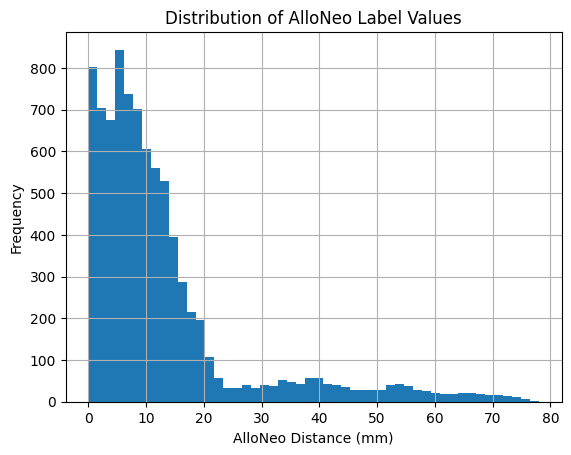

In [ ]:
import matplotlib.pyplot as plt
an_lbl = nib.load("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_lbl_AlloNeo_masked-13Feb2026.label.gii")
an_data = an_lbl.darrays[0].data
print(an_data.shape)
print(min(an_data))
print(max(an_data))



In [55]:
lbl = nib.load("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp.label.gii")
print(dir(lbl))

['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_compressed_suffixes', '_filemap_from_iobase', '_header', '_labeltable', '_meta', '_meta_sniff_len', '_sniff_meta_for', '_to_xml_element', 'add_gifti_data_array', 'agg_data', 'darrays', 'extra', 'file_map', 'files_types', 'filespec_to_file_map', 'from_bytes', 'from_file_map', 'from_filename', 'from_image', 'from_stream', 'from_url', 'get_arrays_from_intent', 'get_filename', 'header', 'header_class', 'instance_to_filename', 'labeltable', 'load', 'make_file_map', 'makeable', 'meta', 'numDA', 'parser', 'path_maybe_image', 'print_summary', 'remove_gifti_data_array', 'remove_gifti_data_array_by_intent'

In [78]:
import pyvista as pv

def showVrtxVals(surf_pth, lbl_pth, out_pth=None):
    """
    Visualize vertex values on surface using 4 different camera angles with PyVista
    
    Parameters:
    surf_pth: str - path to surface .gii file
    lbl_pth: str - path to label .gii file  
    out_pth: str - output path for PNG (optional)
    """
    # Load surface and labels
    surf = nib.load(surf_pth)
    vertices = surf.darrays[0].data
    faces = surf.darrays[1].data
    
    lbl = nib.load(lbl_pth)
    values = lbl.darrays[0].data
    
    # Create PyVista mesh
    # Convert faces to PyVista format (add number of vertices per face)
    pv_faces = np.column_stack([np.full(faces.shape[0], 3), faces])
    mesh = pv.PolyData(vertices, pv_faces.flatten())
    mesh['values'] = values
    
    # Create plotter with 2x2 subplot
    plotter = pv.Plotter(shape=(2, 2), off_screen=True if out_pth else False)
    
    # Define camera positions (lateral, medial, anterior, posterior)
    cameras = [
        {'position': (100, 0, 0), 'up': (0, 0, 1), 'title': 'Lateral'},
        {'position': (-100, 0, 0), 'up': (0, 0, 1), 'title': 'Medial'},
        {'position': (0, 100, 0), 'up': (0, 0, 1), 'title': 'Anterior'},
        {'position': (0, -100, 0), 'up': (0, 0, 1), 'title': 'Posterior'}
    ]
    
    # Plot in each subplot
    for i, cam in enumerate(cameras):
        plotter.subplot(i // 2, i % 2)
        plotter.add_mesh(mesh, scalars='values', cmap='viridis', show_scalar_bar=True)
        plotter.camera.position = cam['position']
        plotter.camera.up = cam['up']
        plotter.add_title(cam['title'])
    
    if out_pth:
        plotter.screenshot(out_pth, window_size=(1200, 800))
        print(f"Saved visualization: {out_pth}")
    else:
        plotter.show()
    
    plotter.close()


In [79]:

showVrtxVals(surf_pth="/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched_mask-mTemp-ctx-glsr_hipp-DK25_12Feb2026.surf.gii",
            lbl_pth="/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_lbl_AlloNeo_masked-13Feb2026.label.gii",
            out_pth="/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/sub-Pilot014_ses-a1_stitch_surf_ANcoords.png")

Saved visualization: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/sub-Pilot014_ses-a1_stitch_surf_ANcoords.png


In [80]:
showVrtxVals(surf_pth="/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-Pilot014_ses-a1/surfs/sub-Pilot014_ses-a1_hemi-R_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched_mask-mTemp-ctx-glsr_hipp-DK25_12Feb2026.surf.gii",
            lbl_pth="/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/stitch_lbl_AP_masked-13Feb2026.label.gii",
            out_pth="/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/sub-Pilot014_ses-a1_stitch_surf_APcoords.png")

Saved visualization: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/sub-Pilot014_ses-a1_stitch_surf_APcoords.png
